# Edge Dense Zones Finder: A Hybrid Quantum-Classical Pipeline
[cite_start]**Track:** Track A - Quantum image analysis [cite: 26]

### Project Presentation
* **The Image Problem:** Processing high-resolution images for edge detection can be computationally expensive. [cite_start]We want to identify "edge-dense zones" first, so we only apply intensive edge-detection algorithms to areas of interest[cite: 31, 33].
* [cite_start]**Input Format:** Grayscale image patches[cite: 34].
* [cite_start]**Target Output:** Bounding boxes around dense zones, followed by localized edge-detected crops[cite: 35].
* [cite_start]**Classical Baseline:** Applying standard OpenCV Canny edge detection across the entire uncropped image[cite: 37].
* **Quantum Approach (NEQR):** We utilize the Novel Enhanced Quantum Representation (NEQR) to encode image patches. Because NEQR stores pixel values in computational basis states, it requires a shallower circuit depth than FRQI. [cite_start]We leverage this to estimate the variance/density of regions by measuring the spread of pixel intensities, filtering out "flat" or empty zones[cite: 43, 50].
* **Selling Point:** By skipping empty or uniform regions using quantum evaluation, we drastically reduce the pixel area that classical algorithms (OpenCV) need to process.

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService


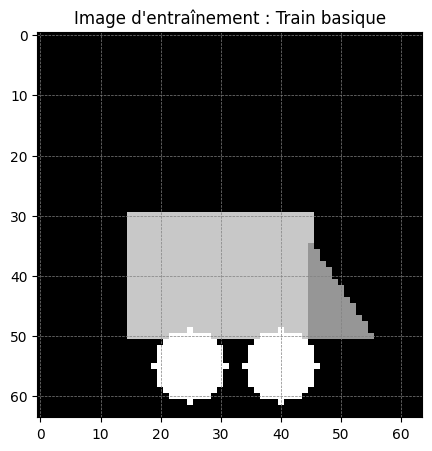

In [8]:
# Cellule : Génération d'une image simple (Carré, Triangle, Cercles)
# Idéal pour tester la logique de seuil de variance du NEQR


# 1. Créer une toile de fond noire (64x64 pour rester léger pour la simulation)
img_size = 64
toy_image = np.zeros((img_size, img_size), dtype=np.uint8)

# 2. Dessiner un Carré (Le corps du train) - Intensité 200 (gris clair)
cv2.rectangle(toy_image, (15, 30), (45, 50), 200, -1)

# 3. Dessiner un Triangle (L'avant du train / chasse-pierres) - Intensité 150 (gris moyen)
triangle_pts = np.array([[45, 50], [45, 35], [55, 50]], np.int32)
cv2.fillPoly(toy_image, [triangle_pts], 150)

# 4. Dessiner des Cercles (Les roues) - Intensité 255 (blanc)
cv2.circle(toy_image, (25, 55), 6, 255, -1)
cv2.circle(toy_image, (40, 55), 6, 255, -1)

# Pour les besoins du pipeline, on l'assigne à la variable 'image'
image = toy_image

# Affichage de l'image de test
plt.figure(figsize=(5,5))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Image d'entraînement : Train basique")
plt.axis('on') # On garde les axes pour visualiser les pixels et les "patches"
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

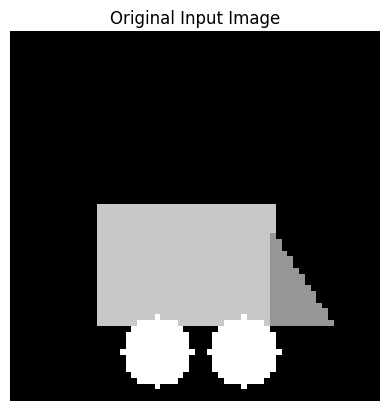

In [9]:
# Cell 2: Dependencies and Run Guide
# Run Guide: Ensure you have qiskit, opencv-python, numpy, and matplotlib installed.
# This prototype is designed to run locally using the Qiskit Aer simulator.

# ---------------------------------------------------------
# INPUT SELECTION
# ---------------------------------------------------------
# If using a real image file, uncomment the following two lines:
# image_path = 'sample_image.jpg'
# original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Since we are using the generated toy data, we assign it directly:
original_image = toy_image

# Resize for proof-of-concept simulation speed 
# (toy_image is already 64x64, but keeping this ensures real images are scaled down later)
target_size = (64, 64) 
image = cv2.resize(original_image, target_size)

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Original Input Image")
plt.axis('off')
plt.show()

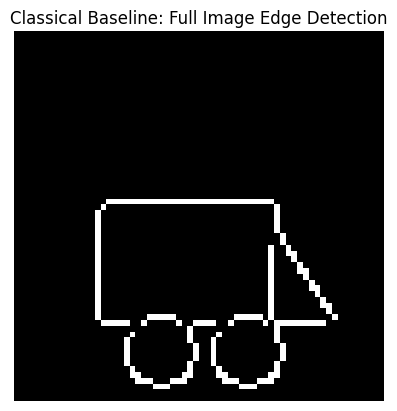

In [10]:
# Cell 3: The Classical Baseline
# Here we demonstrate the computationally heavy approach: running edge detection on the entire image.

def classical_baseline_pipeline(img):
    # Full image edge detection
    edges = cv2.Canny(img, threshold1=100, threshold2=200)
    return edges

baseline_edges = classical_baseline_pipeline(image)

plt.imshow(baseline_edges, cmap='gray')
plt.title("Classical Baseline: Full Image Edge Detection")
plt.axis('off')
plt.show()

### Identifying Dense Zones using NEQR
In this step, we break the image into smaller patches (e.g., 8x8 or 16x16). 
[cite_start]Instead of decoration, the quantum component plays a functional role[cite: 42, 43]: 
1. Encode each patch using **NEQR**.
2. Measure the state to sample the pixel intensity distribution.
3. If the variance/spread of the measured basis states is above a certain threshold, it indicates a "dense" zone with varying textures or edges.
4. If it's below the threshold, it's a flat/uniform zone, and we ignore it.

In [11]:
# Cell 5: Quantum Dense Zone Evaluation (NEQR Implementation)

# ---------------------------------------------------------
# 1. IBM Quantum Cloud Authentication (PINQ2)
# ---------------------------------------------------------
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token="XTniEHDa4bWL-isMEF69tkfj0RyEcO7NNXv4kZjNHyx0",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/d2c50f33c43a44abb94280706332351d:fa6ae649-f03a-4eb4-9434-1c3f512203fe::"
)

# Target the specific processor from your dashboard
backend_real = service.backend("ibm_quebec")
backend_sim = AerSimulator()

# ---------------------------------------------------------
# 2. NEQR Circuit Builder
# ---------------------------------------------------------
def encode_neqr(patch):
    """
    Builds the NEQR Quantum Circuit for a given 2D grayscale image patch.
    """
    flat_patch = patch.flatten()
    num_pixels = len(flat_patch)

    # Calculate required qubits
    n_pos = int(np.ceil(np.log2(num_pixels))) # Qubits needed for position (e.g., 4x4 patch = 16 pixels = 4 qubits)
    n_color = 8                               # Qubits needed for 8-bit grayscale color (0-255)
    
    # Circuit: Position qubits first, then color qubits
    qc = QuantumCircuit(n_pos + n_color, n_color)

    # Put position qubits into a uniform superposition
    for i in range(n_pos):
        qc.h(i)

    # Encode each pixel into the color register
    for pos, pixel_value in enumerate(flat_patch):
        if pixel_value == 0:
            continue # Skip pure black pixels to save circuit depth
        
        # Get binary representations
        pos_bin = format(pos, f'0{n_pos}b')
        color_bin = format(int(pixel_value), f'0{n_color}b')

        # Activate multi-controlled NOTs by flipping position qubits matching the '0's
        for i, bit in enumerate(reversed(pos_bin)):
            if bit == '0':
                qc.x(i)

        # Apply Multi-Controlled X (MCX) to the color qubits where the binary value is '1'
        for j, bit in enumerate(reversed(color_bin)):
            if bit == '1':
                qc.mcx(list(range(n_pos)), n_pos + j)

        # Uncompute position qubits to reset for the next pixel
        for i, bit in enumerate(reversed(pos_bin)):
            if bit == '0':
                qc.x(i)

    # Measure ONLY the color register (mapping qubits to classical bits)
    qc.measure(range(n_pos, n_pos + n_color), range(n_color))
    
    return qc

# ---------------------------------------------------------
# 3. Execution and Variance Calculation
# ---------------------------------------------------------
def evaluate_patch_density_neqr(patch, use_real_hardware=False):
    """
    Builds and executes the NEQR circuit, reconstructing variance from shots.
    """
    qc = encode_neqr(patch)
    
    if use_real_hardware:
        # Run on Heron r2 (ibm_quebec)
        transpiled_qc = transpile(qc, backend=backend_real, optimization_level=2)
        job = backend_real.run(transpiled_qc, shots=1024)
        print(f"Job sent to ibm_quebec. Job ID: {job.job_id()}")
    else:
        # Run locally on AerSimulator
        transpiled_qc = transpile(qc, backend=backend_sim)
        job = backend_sim.run(transpiled_qc, shots=1024)
        
    result = job.result()
    counts = result.get_counts()

    # Reconstruct pixel intensities from measurement counts
    measured_values = []
    for bitstring, count in counts.items():
        intensity = int(bitstring, 2)
        measured_values.extend([intensity] * count)
        
    # Calculate the variance of the sampled intensities
    variance = np.var(measured_values)
    density_threshold = 500 # Tune this threshold based on your dataset
    
    return variance > density_threshold

# ---------------------------------------------------------
# 4. Processing the Image
# ---------------------------------------------------------
patch_size = 4 # Kept at 4x4 to ensure viable circuit depth
dense_zones = []

# Loop over the image in blocks of `patch_size`
# Note: For initial proof-of-concept testing, keep use_real_hardware=False 
# to avoid long queue times on the real QPU for every single patch.
for y in range(0, image.shape[0], patch_size):
    for x in range(0, image.shape[1], patch_size):
        patch = image[y:y+patch_size, x:x+patch_size]
        
        # Evaluate density
        is_dense = evaluate_patch_density_neqr(patch, use_real_hardware=False)
        
        if is_dense:
            dense_zones.append((x, y, patch_size, patch_size))

print(f"Identified {len(dense_zones)} dense zones using NEQR evaluation.")

qiskit_runtime_service._discover_account:WARNING:2026-06-01 18:31:00,062: Loading account with the given token. A saved account will not be used.


Identified 42 dense zones using NEQR evaluation.


--- Pipeline Results ---
Total image patches: 256
Patches processed classically (OpenCV): 42
Classical Processing Workload Reduction: 83.59%



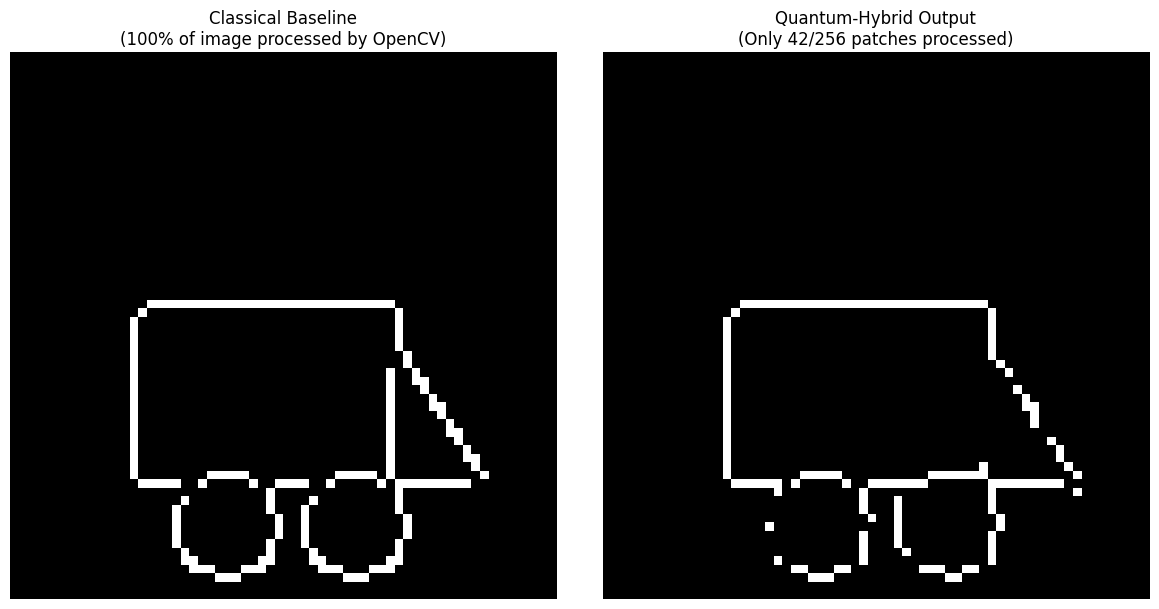

In [12]:
# Cell 6: Hybrid Recombination & Output
# We now crop the original image using the coordinates from `dense_zones`,
# apply OpenCV strictly to those crops, and reconstruct the final image.

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create an empty black canvas of the same shape as the original image
hybrid_output = np.zeros_like(image)

# Loop through the coordinates found by the NEQR quantum evaluation
for (x, y, w, h) in dense_zones:
    # 1. Crop the specific dense zone from the original image
    crop = image[y:y+h, x:x+w]
    
    # 2. Apply OpenCV Canny edge detection strictly to this small crop
    crop_edges = cv2.Canny(crop, threshold1=100, threshold2=200)
    
    # 3. Place the edge-detected crop back into its original position on the final canvas
    hybrid_output[y:y+h, x:x+w] = crop_edges

# Calculate metrics to highlight the "Selling Point" of your pipeline
total_patches = (image.shape[0] // patch_size) * (image.shape[1] // patch_size)
processed_patches = len(dense_zones)
reduction_percentage = 100 - ((processed_patches / total_patches) * 100)

print("--- Pipeline Results ---")
print(f"Total image patches: {total_patches}")
print(f"Patches processed classically (OpenCV): {processed_patches}")
print(f"Classical Processing Workload Reduction: {reduction_percentage:.2f}%\n")

# Visualization: Compare the Baseline with your Hybrid Pipeline
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Display the baseline (from Cell 3)
ax[0].imshow(baseline_edges, cmap='gray')
ax[0].set_title("Classical Baseline\n(100% of image processed by OpenCV)")
ax[0].axis('off')

# Display the hybrid result
ax[1].imshow(hybrid_output, cmap='gray')
ax[1].set_title(f"Quantum-Hybrid Output\n(Only {processed_patches}/{total_patches} patches processed)")
ax[1].axis('off')

plt.tight_layout()
plt.show()